# Ансамблирование

## 1. Загрузка данных

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
                              StackingClassifier)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

plt.rcParams['figure.figsize'] = (11, 6)
RANDOM_STATE = 42
df = pd.read_csv('heart.csv')
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [3]:
print('Пропуски:', df.isnull().sum().sum())
print('\nБаланс целевой переменной HeartDisease:')
print(df['HeartDisease'].value_counts())
print((df['HeartDisease'].value_counts(normalize=True) * 100).round(1).astype(str) + ' %')

Пропуски: 0

Баланс целевой переменной HeartDisease:
HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.3 %
0    44.7 %
Name: proportion, dtype: str


Пропусков нет, классы сбалансированы (≈55% больных / 45% здоровых). Пять признаков категориальные: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.

## 2. Подготовка данных

### 2b. Полезные графики (до кодирования — на исходных категориях)

Сначала посмотрим на данные, пока категории читаемы.

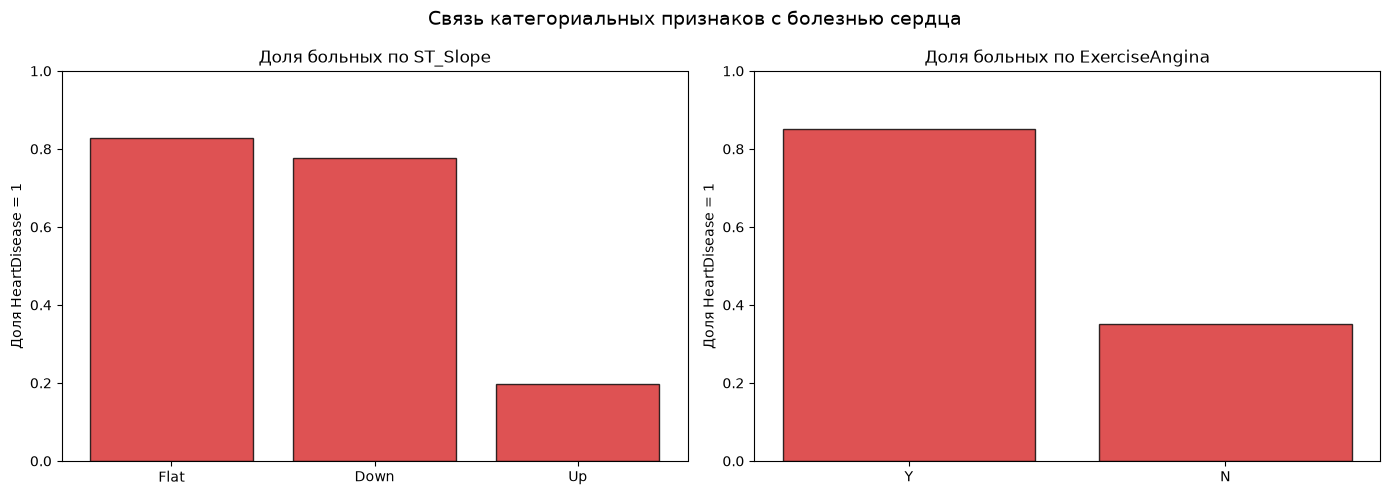

In [4]:
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['ST_Slope', 'ExerciseAngina']):
    rate = df.groupby(col)['HeartDisease'].mean().sort_values(ascending=False)
    ax.bar(rate.index, rate.values, color='tab:red', edgecolor='black', alpha=0.8)
    ax.set_title(f'Доля больных по {col}')
    ax.set_ylabel('Доля HeartDisease = 1')
    ax.set_ylim(0, 1)
plt.suptitle('Связь категориальных признаков с болезнью сердца', fontsize=14)
plt.tight_layout()
plt.show()

**Вывод по графику 1:** признаки сильно разделяют классы. Плоский/нисходящий наклон ST-сегмента (`Flat`, `Down`) и наличие стенокардии при нагрузке (`ExerciseAngina = Y`) резко повышают долю больных — это мощные предикторы.

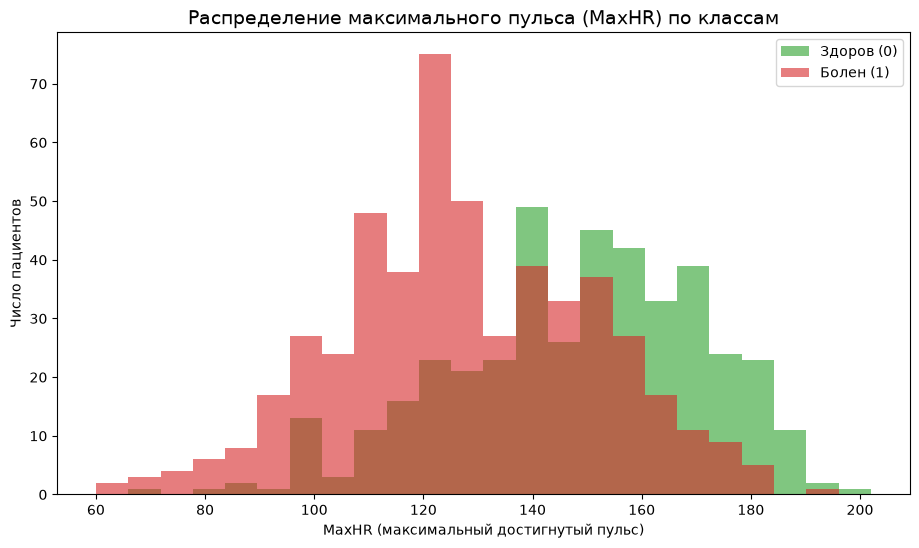

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
bins = np.linspace(df['MaxHR'].min(), df['MaxHR'].max(), 25)
ax.hist(df.loc[df['HeartDisease'] == 0, 'MaxHR'], bins=bins, alpha=0.6,
        label='Здоров (0)', color='tab:green')
ax.hist(df.loc[df['HeartDisease'] == 1, 'MaxHR'], bins=bins, alpha=0.6,
        label='Болен (1)', color='tab:red')
ax.set_title('Распределение максимального пульса (MaxHR) по классам', fontsize=14)
ax.set_xlabel('MaxHR (максимальный достигнутый пульс)')
ax.set_ylabel('Число пациентов')
ax.legend()
plt.show()

**Вывод по графику 2:** у больных максимальный пульс в среднем ниже — распределение смещено влево относительно здоровых. `MaxHR` тоже полезен для классификации.

### 2a. Кодирование категориальных признаков

Переводим категориальные признаки в числовые через `pd.get_dummies` (без циклов). `drop_first=True` убирает избыточный столбец.

In [6]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('Было признаков:', df.shape[1] - 1, '-> стало:', df_encoded.shape[1] - 1)
print('\nСписок признаков после кодирования:')
print(list(df_encoded.drop(columns='HeartDisease').columns))
df_encoded.head()

Было признаков: 11 -> стало: 15

Список признаков после кодирования:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


## 3. Разделение на обучающее и тестовое множества (80/20)

In [7]:
X = df_encoded.drop(columns='HeartDisease')
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка: ', X_test.shape)

Обучающая выборка: (734, 15)
Тестовая выборка:  (184, 15)


## 4–5. Дерево решений и случайный лес

In [8]:
scores = {}

def fit_and_report(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, digits=3))
    scores[name] = {'accuracy': accuracy_score(y_test, y_pred),
                    'f1': f1_score(y_test, y_pred)}
    return model
tree = fit_and_report('DecisionTreeClassifier',
                      DecisionTreeClassifier(random_state=RANDOM_STATE))

              precision    recall  f1-score   support

           0      0.784     0.707     0.744        82
           1      0.782     0.843     0.811       102

    accuracy                          0.783       184
   macro avg      0.783     0.775     0.777       184
weighted avg      0.783     0.783     0.781       184



In [9]:
forest = fit_and_report('RandomForestClassifier',
                        RandomForestClassifier(random_state=RANDOM_STATE))

              precision    recall  f1-score   support

           0      0.864     0.854     0.859        82
           1      0.883     0.892     0.888       102

    accuracy                          0.875       184
   macro avg      0.874     0.873     0.873       184
weighted avg      0.875     0.875     0.875       184



Случайный лес заметно точнее одиночного дерева — усреднение множества деревьев снижает переобучение и дисперсию.

## 6. Важность признаков (случайный лес)

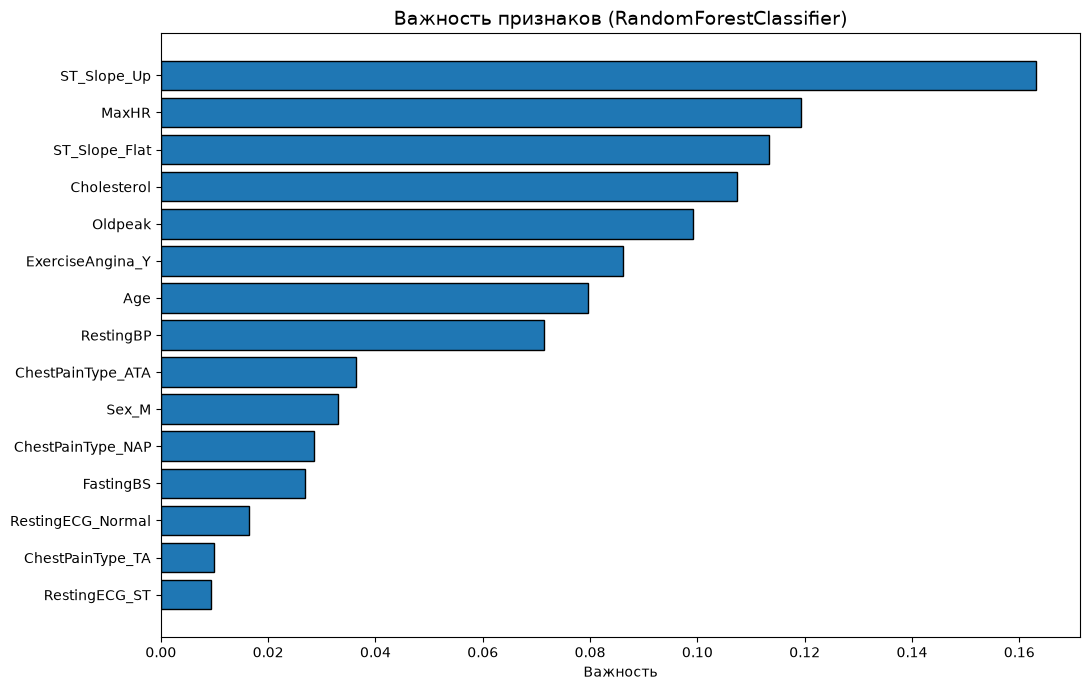

Топ-5 признаков по важности:
ST_Slope_Up      0.1632
MaxHR            0.1192
ST_Slope_Flat    0.1134
Cholesterol      0.1074
Oldpeak          0.0992
dtype: float64


In [10]:
importances = pd.Series(forest.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 7))
plt.barh(importances.index[::-1], importances.values[::-1], color='tab:blue', edgecolor='black')
plt.title('Важность признаков (RandomForestClassifier)', fontsize=14)
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print('Топ-5 признаков по важности:')
print(importances.head().round(4))

**Вывод.** Наиболее важные признаки — `ST_Slope_Up`, `MaxHR`, `ST_Slope_Flat`, `Cholesterol`, `Oldpeak`. Это согласуется с графиками из п. 2b, где наклон ST-сегмента и пульс хорошо разделяли классы.

## 7. Бэггинг над деревом решений

In [11]:
bagging = fit_and_report('BaggingClassifier (over DecisionTree)',
    BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                      n_estimators=50, random_state=RANDOM_STATE))

              precision    recall  f1-score   support

           0      0.863     0.841     0.852        82
           1      0.875     0.892     0.883       102

    accuracy                          0.870       184
   macro avg      0.869     0.867     0.868       184
weighted avg      0.869     0.870     0.869       184



## 8. Стекинг трёх моделей

In [12]:
svc_pipe = make_pipeline(StandardScaler(),
                         LinearSVC(max_iter=5000, random_state=RANDOM_STATE))

stacking = fit_and_report('StackingClassifier (DT + RF + LinearSVC)',
    StackingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE)),
            ('rf', RandomForestClassifier(random_state=RANDOM_STATE)),
            ('svc', svc_pipe),
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5))

              precision    recall  f1-score   support

           0      0.885     0.841     0.863        82
           1      0.877     0.912     0.894       102

    accuracy                          0.880       184
   macro avg      0.881     0.877     0.878       184
weighted avg      0.881     0.880     0.880       184



## 9. Выводы

In [13]:
summary = pd.DataFrame([
    {'Модель': name, 'Accuracy': round(s['accuracy'], 4), 'F1 (класс 1)': round(s['f1'], 4)}
    for name, s in scores.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)
summary

,Модель,Accuracy,F1 (класс 1)
0,StackingClassifier (DT + RF + LinearSVC),0.8804,0.8942
1,RandomForestClassifier,0.8750,0.8878
2,BaggingClassifier (over DecisionTree),0.8696,0.8835
3,DecisionTreeClassifier,0.7826,0.8113


### a) Сравнение метрик моделей
- Одиночное дерево решений — самая слабая модель (accuracy ≈ 0.78): оно переобучается и неустойчиво.
- Ансамбли резко улучшают результат. Бэггинг и случайный лес поднимают accuracy до ~0.87 за счёт усреднения множества деревьев (снижение дисперсии).
- Стекинг — лучший результат (accuracy ≈ 0.88, F1 ≈ 0.89): мета-модель комбинирует сильные стороны разнородных базовых моделей (деревья + линейный SVC).

### b) Какая модель лучшая и почему

Лучшая — стекинг трёх моделей. Он даёт максимальную точность и F1, потому что объединяет разнородные алгоритмы: деревья улавливают нелинейные взаимодействия признаков, а линейный SVC — линейные границы; мета-модель учится оптимально взвешивать их предсказания, компенсируя слабости каждого по отдельности.

Однако, случайный лес — очень близкий по качеству (0.875 против 0.880) и при этом заметно проще, быстрее обучается и не требует настройки нескольких базовых моделей и кросс-валидации внутри стекинга.


**Итог**: ансамблевые методы (бэггинг, случайный лес, стекинг) существенно превосходят одиночное дерево решений в задаче классификации болезни сердца — прирост accuracy составил аж 10 процентов.